# Audit Aircraft-Rotation Matching and Long Turns

This read-only audit compares the rotation features already generated from the project's working-airport cohort with a fuller event history from the raw BTS airport file. The target departure rows never change, and this notebook writes no replacement feature dataset.

The fuller history admits completed arrivals at the target airport from every raw BTS origin. It also includes every noncancelled departure from the target airport as a blocking event, including flights that later diverted. This prevents an older inbound leg from being reused after the aircraft left the airport.

In [1]:
AIRPORT = "JFK"
YEAR = 2019
LONG_TURN_HOURS = [8, 12, 24, 48]
SAMPLE_ROWS = 10

In [2]:
# Parameters
YEAR = 2019
AIRPORT = "JFK"


## Configure and load the three audit inputs

The current rotation feature file supplies the unchanged target population and existing matches. The concatenated cleaned inbound file identifies the working-cohort history used by feature generation. The raw airport file supplies the fuller audit-only movement history.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if (Path.cwd() / "data").is_dir() and (Path.cwd() / "notebooks").is_dir():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == "notebooks" and (Path.cwd().parent / "data").is_dir():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError("Start from the project root or notebooks directory")

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from feature_engineering_rotation import (
    build_full_history_rotation_audit, compare_rotation_histories,
    prepare_rotation_history, summarize_long_turns,
    validate_departure_rotation_features,
)

AIRPORT = str(AIRPORT).strip().upper()
YEAR = int(YEAR)
LONG_TURN_HOURS = [int(value) for value in LONG_TURN_HOURS]
SAMPLE_ROWS = int(SAMPLE_ROWS)
CURRENT_ROTATION_FILE = PROJECT_ROOT / f"data/features/{AIRPORT}_{YEAR}_departures_rotation.csv"
FILTERED_INBOUND_FILE = PROJECT_ROOT / f"data/bts/cleaned_{AIRPORT}_{YEAR}.csv"
RAW_AIRPORT_FILE = PROJECT_ROOT / f"data/bts/raw/{YEAR}/{AIRPORT}.csv"
for path in [CURRENT_ROTATION_FILE, FILTERED_INBOUND_FILE, RAW_AIRPORT_FILE]:
    if not path.is_file():
        raise FileNotFoundError(f"Required audit input does not exist: {path}")
print(pd.Series({
    "current rotation": str(CURRENT_ROTATION_FILE),
    "filtered inbound history": str(FILTERED_INBOUND_FILE),
    "full raw airport history": str(RAW_AIRPORT_FILE),
}))

current rotation            /Users/johnkyte/Projects/berkeley_ml_and_ai/ca...
filtered inbound history    /Users/johnkyte/Projects/berkeley_ml_and_ai/ca...
full raw airport history    /Users/johnkyte/Projects/berkeley_ml_and_ai/ca...
dtype: str


In [4]:
current = pd.read_csv(CURRENT_ROTATION_FILE, low_memory=False)
filtered_inbound = pd.read_csv(FILTERED_INBOUND_FILE, low_memory=False)
raw_airport = pd.read_csv(RAW_AIRPORT_FILE, low_memory=False)
validate_departure_rotation_features(current)
current_year = pd.to_numeric(current["Year"], errors="coerce")
raw_year = pd.to_numeric(raw_airport["Year"], errors="coerce")
assert current_year.eq(YEAR).all() and raw_year.eq(YEAR).all()
assert current["Origin"].astype("string").str.upper().eq(AIRPORT).all()
assert filtered_inbound["Dest"].astype("string").str.upper().eq(AIRPORT).all()
print(pd.Series({
    "target departure rows": len(current),
    "current rotation columns": len(current.columns),
    "filtered inbound rows": len(filtered_inbound),
    "raw airport rows": len(raw_airport),
}))

target departure rows       107430
current rotation columns       133
filtered inbound rows       107354
raw airport rows            254275
dtype: int64


## Compare working-cohort and full-history coverage

This section quantifies the extra completed inbound legs and noncancelled outbound blocking events available in the raw airport history. The list of excluded origins is diagnostic; no ASPM or NOAA data is needed for these intermediate aircraft movements.

In [5]:
full_history = prepare_rotation_history(raw_airport, airport=AIRPORT)
full_inbound = full_history[full_history["Dest"].eq(AIRPORT)]
full_outbound = full_history[full_history["Origin"].eq(AIRPORT)]
filtered_origins = set(filtered_inbound["Origin"].astype("string").str.upper())
full_origins = set(full_inbound["Origin"].astype("string").str.upper())
excluded_origins = sorted(full_origins - filtered_origins)
coverage_summary = pd.Series({
    "filtered completed inbound rows": len(filtered_inbound),
    "full completed inbound rows": len(full_inbound),
    "additional full-history inbound rows": len(full_inbound) - len(filtered_inbound),
    "filtered inbound origins": len(filtered_origins),
    "full inbound origins": len(full_origins),
    "additional origins": len(excluded_origins),
    "full noncancelled outbound events": len(full_outbound),
}, name=f"{AIRPORT} {YEAR} history coverage")
display(coverage_summary.to_frame())
print("Additional raw-history origins:", " ".join(excluded_origins))

,JFK 2019 history coverage
filtered completed inbound rows,107354
full completed inbound rows,124669
additional full-history inbound rows,17315
filtered inbound origins,50
full inbound origins,71
additional origins,21
full noncancelled outbound events,125109


Additional raw-history origins: ACK BQN BTV CHS CMH DAB EGE HYA JAC MVY ORF ORH PSE PWM RIC RNO ROC SAV SRQ STT SYR


## Reconstruct and compare preceding events

The fuller history is used only to calculate an alternative audit match for the same target rows. `MATCH_CHANGE` distinguishes unchanged inbound legs, changed inbound legs, added or removed matches, and unmatched status changes.

In [6]:
full_rotation = build_full_history_rotation_audit(
    current, full_history, airport=AIRPORT
)
comparison = compare_rotation_histories(current, full_rotation)
assert len(full_rotation) == len(current) == len(comparison)
full_match = pd.to_numeric(full_rotation["FULL_ROTATION_MATCH_FOUND"], errors="coerce")
full_arrived = pd.to_numeric(
    full_rotation["FULL_ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="coerce"
)
full_not_arrived = pd.to_numeric(
    full_rotation["FULL_ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="coerce"
)
assert full_match.eq(full_arrived + full_not_arrived).all()
assert pd.to_numeric(
    full_rotation["FULL_ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce"
).dropna().gt(0).all()
assert full_rotation.loc[full_arrived.eq(0), [
    "FULL_ROTATION_ACTUAL_TURN_MINUTES", "FULL_ROTATION_INBOUND_ARR_DELAY",
    "FULL_ROTATION_INBOUND_DELAYED_15",
]].isna().all().all()

match_change_summary = (
    comparison.assign(_TARGET=pd.to_numeric(current["DepDel15"], errors="coerce"))
    .groupby("MATCH_CHANGE", observed=True)
    .agg(rows=("_TARGET", "size"), delay_rate=("_TARGET", "mean"))
    .sort_values("rows", ascending=False)
)
match_change_summary["row_percent"] = match_change_summary["rows"] / len(comparison) * 100
match_change_summary

,rows,delay_rate,row_percent
MATCH_CHANGE,,,
SAME_PRIOR_INBOUND,94019,0.175326,87.516522
DIFFERENT_PRIOR_INBOUND,8443,0.192941,7.859071
BOTH_UNMATCHED,3315,0.478130,3.085730
MATCH_ADDED,1372,0.209913,1.277111
MATCH_REMOVED,279,0.645161,0.259704
UNMATCHED_STATUS_CHANGED,2,1.000000,0.001862


In [7]:
target = pd.to_numeric(current["DepDel15"], errors="coerce")
current_status_rates = (
    pd.DataFrame({"status": comparison["CURRENT_STATUS"], "target": target})
    .groupby("status", observed=True)["target"].agg(["size", "mean"])
    .rename(columns={"size": "rows", "mean": "delay_rate"})
    .assign(history="filtered")
)
full_status_rates = (
    pd.DataFrame({"status": comparison["FULL_STATUS"], "target": target})
    .groupby("status", observed=True)["target"].agg(["size", "mean"])
    .rename(columns={"size": "rows", "mean": "delay_rate"})
    .assign(history="full raw")
)
status_rate_summary = pd.concat([current_status_rates, full_status_rates]).reset_index()
display(status_rate_summary.set_index(["history", "status"]))
status_transition = pd.crosstab(
    comparison["CURRENT_STATUS"], comparison["FULL_STATUS"], margins=True
)
status_transition

rows  delay_rate
history  status                                      
filtered ARRIVED                   100103    0.156449
         NOT_ARRIVED                 2638    0.997726
         NO_PRIOR_EVENT               456    0.234649
         PREVIOUS_EVENT_DEPARTURE    4233    0.417671
full raw ARRIVED                   100701    0.151677
         NOT_ARRIVED                 3133    0.998085
         NO_PRIOR_EVENT               370    0.254054
         PREVIOUS_EVENT_DEPARTURE    3226    0.518599

FULL_STATUS,ARRIVED,NOT_ARRIVED,NO_PRIOR_EVENT,PREVIOUS_EVENT_DEPARTURE,All
CURRENT_STATUS,,,,,
ARRIVED,99412,412,0,279,100103
NOT_ARRIVED,0,2638,0,0,2638
NO_PRIOR_EVENT,81,3,370,2,456
PREVIOUS_EVENT_DEPARTURE,1208,80,0,2945,4233
All,100701,3133,370,3226,107430


## Audit long scheduled turns

Long turns are counted, not automatically rejected. `current_long_resolved` means a target exceeded the threshold under the filtered history but no longer does under fuller history. `new_full_history_long` captures movement in the opposite direction.

In [8]:
long_turn_summary = summarize_long_turns(
    comparison, thresholds_hours=LONG_TURN_HOURS
)
long_turn_summary

,current_count,full_history_count,count_change,current_percent,full_history_percent,current_long_resolved,new_full_history_long
threshold_hours,,,,,,,
8,35638,30557,-5081,33.173229,28.443638,5252,171
12,22665,18812,-3853,21.097459,17.510937,3966,113
24,10668,8281,-2387,9.930187,7.708275,2417,30
48,4276,3080,-1196,3.980266,2.866983,1204,8


In [9]:
turn_distribution = pd.DataFrame({
    "current_minutes": comparison["CURRENT_SCHEDULED_TURN_MINUTES"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "full_history_minutes": comparison["FULL_SCHEDULED_TURN_MINUTES"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
})
turn_distribution

,current_minutes,full_history_minutes
count,102741.000000,103834.000000
mean,943.241364,721.109993
std,5088.372075,4188.481402
min,1.000000,1.000000
50%,121.000000,93.000000
75%,660.000000,558.000000
90%,1493.000000,1230.000000
95%,2580.000000,2119.000000
99%,13383.600000,8485.670000
max,330752.000000,330752.000000


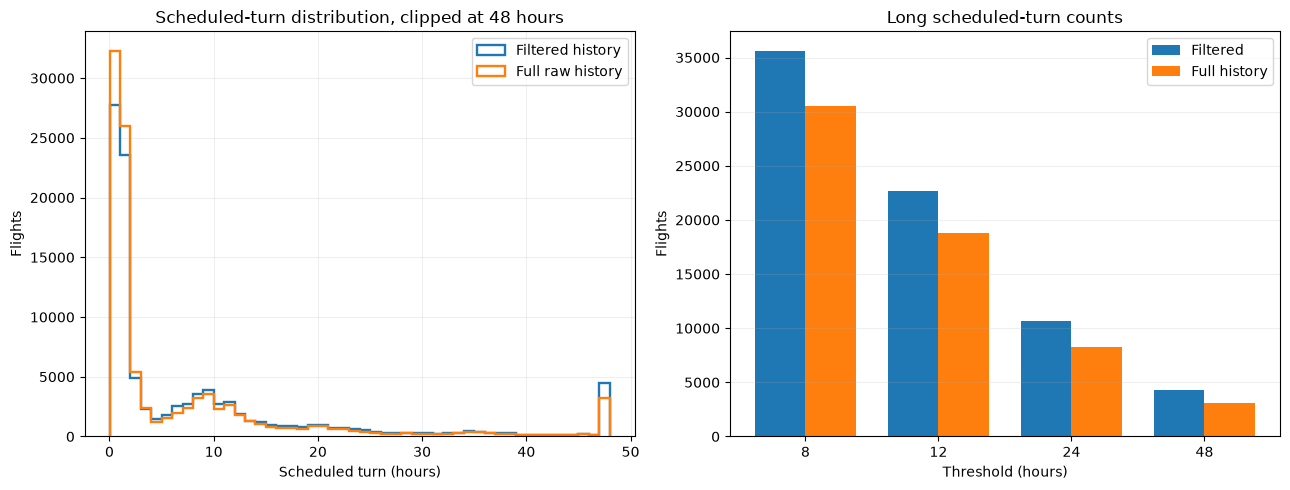

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for column, label in [("CURRENT_SCHEDULED_TURN_MINUTES", "Filtered history"),
                      ("FULL_SCHEDULED_TURN_MINUTES", "Full raw history")]:
    values = comparison[column].dropna().clip(upper=48 * 60)
    axes[0].hist(values / 60, bins=48, histtype="step", linewidth=1.7, label=label)
axes[0].set(title="Scheduled-turn distribution, clipped at 48 hours",
            xlabel="Scheduled turn (hours)", ylabel="Flights")
axes[0].legend(); axes[0].grid(alpha=0.2)
x = np.arange(len(long_turn_summary.index)); width = 0.38
axes[1].bar(x - width/2, long_turn_summary["current_count"], width, label="Filtered")
axes[1].bar(x + width/2, long_turn_summary["full_history_count"], width, label="Full history")
axes[1].set(title="Long scheduled-turn counts", xlabel="Threshold (hours)", ylabel="Flights",
            xticks=x, xticklabels=long_turn_summary.index.astype(str))
axes[1].legend(); axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout(); plt.show()

## Inspect representative changed and long matches

These samples support manual review. They are selected deterministically by largest absolute turn change or longest full-history turn; they do not alter any audit result.

In [11]:
sample_columns = [
    "FlightDate", "Reporting_Airline", "Tail_Number",
    "Flight_Number_Reporting_Airline", "Dest", "CRSDepTime", "DepDel15",
]
sample_frame = pd.concat([
    current[sample_columns], comparison,
    current[["ROTATION_INBOUND_ORIGIN"]].rename(
        columns={"ROTATION_INBOUND_ORIGIN": "CURRENT_INBOUND_ORIGIN"}
    ),
    full_rotation[["FULL_ROTATION_INBOUND_ORIGIN",
                   "FULL_ROTATION_PRIOR_REPORTING_AIRLINE",
                   "FULL_ROTATION_PRIOR_FLIGHT_NUMBER"]],
], axis=1)
changed_samples = (
    sample_frame[sample_frame["MATCH_CHANGE"].ne("SAME_PRIOR_INBOUND")]
    .assign(_ABS_TURN_CHANGE=lambda frame: frame["TURN_CHANGE_MINUTES"].abs())
    .sort_values(["_ABS_TURN_CHANGE", "FlightDate"], ascending=[False, True])
    .drop(columns="_ABS_TURN_CHANGE")
    .head(SAMPLE_ROWS)
)
display(changed_samples)
longest_full_history_samples = sample_frame.sort_values(
    "FULL_SCHEDULED_TURN_MINUTES", ascending=False
).head(SAMPLE_ROWS)
longest_full_history_samples

,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Dest,CRSDepTime,DepDel15,CURRENT_STATUS,FULL_STATUS,CURRENT_MATCH_FOUND,...,FULL_SCHEDULED_TURN_MINUTES,TURN_CHANGE_MINUTES,MATCH_CHANGE,STATUS_CHANGED,CURRENT_PRIOR_SCHEDULED_ARRIVAL_UTC,FULL_PRIOR_SCHEDULED_ARRIVAL_UTC,CURRENT_INBOUND_ORIGIN,FULL_ROTATION_INBOUND_ORIGIN,FULL_ROTATION_PRIOR_REPORTING_AIRLINE,FULL_ROTATION_PRIOR_FLIGHT_NUMBER
74133,2019-09-08,9E,N8688C,5042,IAD,1329,0.0,ARRIVED,ARRIVED,1,...,44.0,-249262.0,DIFFERENT_PRIOR_INBOUND,False,2019-03-19 14:23:00,2019-09-08 16:45:00,BWI,PWM,9E,3431
101798,2019-12-12,9E,N8908D,5080,BWI,1355,1.0,ARRIVED,ARRIVED,1,...,42.0,-165213.0,DIFFERENT_PRIOR_INBOUND,False,2019-08-20 00:40:00,2019-12-12 18:13:00,BWI,ORF,9E,5112
79040,2019-09-24,9E,N8886A,3434,BWI,2130,0.0,ARRIVED,ARRIVED,1,...,84.0,-152809.0,DIFFERENT_PRIOR_INBOUND,False,2019-06-10 21:17:00,2019-09-25 00:06:00,IAD,BTV,9E,5092
44523,2019-05-29,9E,N8928A,3492,IAD,2130,0.0,ARRIVED,ARRIVED,1,...,1958.0,-148355.0,DIFFERENT_PRIOR_INBOUND,False,2019-02-14 16:17:00,2019-05-28 16:52:00,IAD,SYR,9E,5177
82592,2019-10-06,9E,N820AY,3351,IAD,2130,0.0,ARRIVED,ARRIVED,1,...,81.0,-143149.0,DIFFERENT_PRIOR_INBOUND,False,2019-06-29 14:20:00,2019-10-07 00:09:00,BWI,BTV,9E,5092
106641,2019-12-29,9E,N8836A,5335,IAD,815,0.0,ARRIVED,ARRIVED,1,...,37.0,-135253.0,DIFFERENT_PRIOR_INBOUND,False,2019-09-26 14:25:00,2019-12-29 12:38:00,BWI,PWM,9E,5091
67490,2019-08-15,9E,N833AY,5397,BWI,2200,0.0,ARRIVED,ARRIVED,1,...,115.0,-126965.0,DIFFERENT_PRIOR_INBOUND,False,2019-05-19 20:00:00,2019-08-16 00:05:00,BWI,BTV,9E,5092
106066,2019-12-27,9E,N819AY,5177,BWI,910,0.0,ARRIVED,ARRIVED,1,...,92.0,-126613.0,DIFFERENT_PRIOR_INBOUND,False,2019-09-30 14:25:00,2019-12-27 12:38:00,BWI,PWM,9E,5091
60839,2019-07-24,9E,N8974C,5042,IAD,1330,0.0,ARRIVED,ARRIVED,1,...,40.0,-122721.0,DIFFERENT_PRIOR_INBOUND,False,2019-04-30 11:29:00,2019-07-24 16:50:00,IAD,SYR,9E,5177
92940,2019-11-11,9E,N924EV,3351,IAD,2129,1.0,ARRIVED,NOT_ARRIVED,1,...,74.0,-121556.0,DIFFERENT_PRIOR_INBOUND,True,2019-08-19 15:19:00,2019-11-12 01:15:00,IAD,BTV,9E,5092


,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Dest,CRSDepTime,DepDel15,CURRENT_STATUS,FULL_STATUS,CURRENT_MATCH_FOUND,...,FULL_SCHEDULED_TURN_MINUTES,TURN_CHANGE_MINUTES,MATCH_CHANGE,STATUS_CHANGED,CURRENT_PRIOR_SCHEDULED_ARRIVAL_UTC,FULL_PRIOR_SCHEDULED_ARRIVAL_UTC,CURRENT_INBOUND_ORIGIN,FULL_ROTATION_INBOUND_ORIGIN,FULL_ROTATION_PRIOR_REPORTING_AIRLINE,FULL_ROTATION_PRIOR_FLIGHT_NUMBER
78234,2019-09-22,DL,N801NW,1085,LAX,955,0.0,ARRIVED,ARRIVED,1,...,330752.0,0.0,SAME_PRIOR_INBOUND,False,2019-02-04 21:23:00,2019-02-04 21:23:00,LAX,LAX,DL,1891
94340,2019-11-16,DL,N851NW,1169,ATL,1655,0.0,ARRIVED,ARRIVED,1,...,309839.0,0.0,SAME_PRIOR_INBOUND,False,2019-04-15 17:56:00,2019-04-15 17:56:00,MSP,MSP,DL,2583
72620,2019-09-02,DL,N812NW,2875,ATL,1854,1.0,ARRIVED,ARRIVED,1,...,282101.0,0.0,SAME_PRIOR_INBOUND,False,2019-02-19 01:13:00,2019-02-19 01:13:00,LAX,LAX,DL,1862
55900,2019-07-07,DL,N154DL,447,LAX,1815,0.0,ARRIVED,ARRIVED,1,...,203199.0,0.0,SAME_PRIOR_INBOUND,False,2019-02-16 19:36:00,2019-02-16 19:36:00,LAX,LAX,DL,1876
49685,2019-06-16,DL,N3753,2154,PHX,815,0.0,ARRIVED,ARRIVED,1,...,193033.0,0.0,SAME_PRIOR_INBOUND,False,2019-02-02 11:02:00,2019-02-02 11:02:00,SAN,SAN,DL,2916
105505,2019-12-25,DL,N833MH,1518,MCO,928,1.0,ARRIVED,ARRIVED,1,...,165046.0,0.0,SAME_PRIOR_INBOUND,False,2019-09-01 23:42:00,2019-09-01 23:42:00,LAX,LAX,DL,468
68162,2019-08-18,DL,N839MH,1085,LAX,959,0.0,ARRIVED,ARRIVED,1,...,157798.0,0.0,SAME_PRIOR_INBOUND,False,2019-05-01 00:01:00,2019-05-01 00:01:00,LAX,LAX,DL,816
34494,2019-04-26,DL,N155DL,1273,SFO,940,1.0,ARRIVED,ARRIVED,1,...,156599.0,0.0,SAME_PRIOR_INBOUND,False,2019-01-07 19:41:00,2019-01-07 19:41:00,LAX,LAX,DL,1876
55794,2019-07-07,DL,N3744F,2571,SJU,1150,1.0,ARRIVED,ARRIVED,1,...,151539.0,0.0,SAME_PRIOR_INBOUND,False,2019-03-24 10:11:00,2019-03-24 10:11:00,SLC,SLC,DL,1505
73121,2019-09-04,DL,N1604R,447,LAX,1815,0.0,ARRIVED,ARRIVED,1,...,145657.0,0.0,SAME_PRIOR_INBOUND,False,2019-05-26 18:38:00,2019-05-26 18:38:00,LAX,LAX,DL,1436


## Check schedule reconstruction residuals and summarize the audit

The schedule residual compares reconstructed UTC elapsed time with BTS `CRSElapsedTime`. Small daylight-saving or source-schedule discrepancies remain visible rather than being silently treated as exact.

In [12]:
current_residual = pd.to_numeric(
    current["ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES"], errors="coerce"
)
full_residual = pd.to_numeric(
    full_rotation["FULL_ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES"], errors="coerce"
)
residual_summary = pd.DataFrame({
    "filtered_history": {
        "matched rows": current_residual.notna().sum(),
        "residual > 1 minute": current_residual.gt(1).sum(),
        "maximum residual minutes": current_residual.max(),
    },
    "full_history": {
        "matched rows": full_residual.notna().sum(),
        "residual > 1 minute": full_residual.gt(1).sum(),
        "maximum residual minutes": full_residual.max(),
    },
})
residual_summary

,filtered_history,full_history
matched rows,102741.0,103834.0
residual > 1 minute,11.0,11.0
maximum residual minutes,60.0,60.0


In [13]:
same_prior = comparison["MATCH_CHANGE"].eq("SAME_PRIOR_INBOUND")
different_prior = comparison["MATCH_CHANGE"].eq("DIFFERENT_PRIOR_INBOUND")
audit_summary = pd.Series({
    "airport": AIRPORT, "year": YEAR, "target rows": len(current),
    "current match rate": comparison["CURRENT_MATCH_FOUND"].mean(),
    "full-history match rate": comparison["FULL_MATCH_FOUND"].mean(),
    "same prior inbound rows": int(same_prior.sum()),
    "different prior inbound rows": int(different_prior.sum()),
    "different prior inbound percent": different_prior.mean() * 100,
    "match added rows": int(comparison["MATCH_CHANGE"].eq("MATCH_ADDED").sum()),
    "match removed rows": int(comparison["MATCH_CHANGE"].eq("MATCH_REMOVED").sum()),
    "status changed rows": int(comparison["STATUS_CHANGED"].sum()),
    "current turns over 24 hours": int(
        comparison["CURRENT_SCHEDULED_TURN_MINUTES"].gt(24 * 60).sum()
    ),
    "full-history turns over 24 hours": int(
        comparison["FULL_SCHEDULED_TURN_MINUTES"].gt(24 * 60).sum()
    ),
    "feature files written": 0,
}, name="rotation audit summary")
audit_summary.to_frame()

,rotation audit summary
airport,JFK
year,2019
target rows,107430
current match rate,0.956353
full-history match rate,0.966527
same prior inbound rows,94019
different prior inbound rows,8443
different prior inbound percent,7.859071
match added rows,1372
match removed rows,279


## Interpretation rules

- A changed match demonstrates sensitivity to the working-airport history, not automatically an error in the fuller match.
- A long turn is a review condition, not an automatic exclusion rule. Same-year boundaries, maintenance stays, non-reporting operations, and final-tail assignment can all contribute.
- Any revised feature dataset must use a new append-only name and must be followed by a new model experiment.
- This audit cannot resolve the separate limitation that BTS records the final operated tail rather than a timestamped prediction-time assignment.